# Line Signal Bussed Ramsey Coherence Estimation

This notebook is a simplified copy of `Line_signal_compensation_bussed_ramsey.ipynb`.
It keeps the same PD-file/log ingest pattern from that notebook, but discards the sine fitting and line-signal theory analysis. The analysis here extracts the phase-index-0 ket-0 population for compensated and uncompensated data, plots both on the same axis, and estimates the first crossing of the absolute `1/e` population level.


In [16]:
# Same ingest style as Line_signal_compensation_bussed_ramsey.ipynb
import os
import re
import ast
import json
import math
from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path(r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation")

# These are the same source locations used by Line_signal_compensation_bussed_ramsey.ipynb.
directory_path = r"Z:\Lab Data\Qudit_Ramsey_raw_data\Bussed_ramsey_detuning_calibration_data"
Z_drive_raw_data = r"Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data"
log_path = NOTEBOOK_DIR / "Bussed_Ramsey_datetime_log.txt"

# Edit this transition pair before running the analysis.
target_transitions = [[0, 3,1], [0, 2, 0]]  # [[m,F,mF],[m,F,mF]]

# Index 0 is the nominal zero-phase point used for the coherence estimate.
ZERO_PHASE_INDEX = 0
T2_THRESHOLD = 1.0 / math.e

OUTPUT_FIGURE = NOTEBOOK_DIR / "line_signal_bussed_ramsey_zero_phase_coherence.png"
OUTPUT_TABLE = NOTEBOOK_DIR / "line_signal_bussed_ramsey_zero_phase_coherence.csv"


def parse_filename(filename):
    pattern = (
        r"Ramsey_experiment_\[\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\],\s*"
        r"\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\]\]_(\d+(?:\.\d+)?)_us_(\d+)_"
        r"(\d{8})_(\d{4})"
    )
    match = re.search(pattern, filename)
    if match:
        m1 = int(match.group(1))
        F1 = int(match.group(2))
        mF1 = int(match.group(3))
        m2 = int(match.group(4))
        F2 = int(match.group(5))
        mF2 = int(match.group(6))
        wait_time = float(match.group(7))
        comp_flag = int(match.group(8))
        date_str = match.group(9) + match.group(10)
        date_time = datetime.strptime(date_str, "%Y%m%d%H%M")
        transitions = [(m1, F1, mF1), (m2, F2, mF2)]
        return transitions, wait_time, date_time, comp_flag
    return None, None, None, None


def extract_raw_data_filenames(file_path):
    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = [line.strip() for line in file if line.strip()]
    if not lines:
        return []

    raw_data_filenames_line = lines[-1]
    try:
        parsed = ast.literal_eval(raw_data_filenames_line)
    except Exception:
        parsed = [
            name.strip().strip("'\"")
            for name in raw_data_filenames_line.strip("[]").split(",")
            if name.strip()
        ]

    if isinstance(parsed, (list, tuple)):
        return [str(item).strip() for item in parsed if str(item).strip()]
    return [str(parsed).strip()]


def search_files_by_transitions(directory, target_transitions, target_date_times=None):
    """
    Same search pattern as Line_signal_compensation_bussed_ramsey.ipynb:
    exact transition-pair match, then optional datetime filter from the log.
    """
    target_transitions = [tuple(t) for t in target_transitions]
    records = []
    final_transitions = None

    for filename in sorted(os.listdir(directory)):
        if not filename.startswith("Ramsey_experiment"):
            continue

        transitions, wait_time, date_time, comp_flag = parse_filename(filename)
        if transitions is None or wait_time is None or date_time is None:
            continue

        if transitions == target_transitions:
            if target_date_times and date_time not in target_date_times:
                continue

            final_transitions = transitions
            file_path = Path(directory) / filename
            raw_data_filenames = extract_raw_data_filenames(file_path)
            raw_data_filepaths = [
                Path(Z_drive_raw_data) / raw_filename
                for raw_filename in raw_data_filenames
            ]
            records.append(
                {
                    "wait_time_us": float(wait_time),
                    "date_time": date_time,
                    "comp_flag": int(comp_flag),
                    "pd_file": file_path,
                    "raw_data_filepaths": raw_data_filepaths,
                }
            )

    return records, final_transitions


def parse_log_file_for_pair(log_path, target_transitions, LT_comp: bool):
    """
    Same log interpretation as Line_signal_compensation_bussed_ramsey.ipynb.
    Returns datetimes from the Comp False or Comp True list for one transition pair.
    """
    tkey = (tuple(target_transitions[0]), tuple(target_transitions[1]))
    dt_set = set()
    mean_dev = None

    def _tok_to_dt(tok: str) -> datetime:
        return datetime.strptime(tok.replace("_", ""), "%Y%m%d%H%M")

    with open(log_path, "r", encoding="utf-8", errors="replace") as file:
        for raw_line in file:
            line = raw_line.strip()
            if not line or line.lower().startswith("transition"):
                continue

            end = line.find("]]" )
            if end == -1:
                continue

            trans_str = line[: end + 2].strip()
            rest = line[end + 2 :].strip()
            match = re.match(
                r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
                r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*$",
                trans_str,
            )
            if not match:
                continue

            p1 = (int(match.group(1)), int(match.group(2)), int(match.group(3)))
            p2 = (int(match.group(4)), int(match.group(5)), int(match.group(6)))
            if (p1, p2) != tkey:
                continue

            rest_clean = rest.lstrip(",").strip()
            mean_match = re.search(r"([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)", rest_clean)
            if mean_match:
                mean_dev = float(mean_match.group(1))

            list_blobs = re.findall(r"\[(.*?)\]", rest_clean)
            dt_lists = []
            for blob in list_blobs:
                tokens = re.findall(r"['\"](\d{8}_\d{4})['\"]", blob)
                if tokens:
                    dt_lists.append(tokens)

            comp_false_tokens = dt_lists[0] if len(dt_lists) >= 1 else []
            comp_true_tokens = dt_lists[1] if len(dt_lists) >= 2 else []
            chosen = comp_true_tokens if LT_comp else comp_false_tokens
            for token in chosen:
                dt_set.add(_tok_to_dt(token))

    return dt_set, mean_dev


def load_records_for_transition(target_transitions):
    all_records = {False: [], True: []}
    mean_devs = {False: None, True: None}
    final_transitions = None

    for lt_comp in [False, True]:
        target_date_times, mean_dev = parse_log_file_for_pair(log_path, target_transitions, LT_comp=lt_comp)
        mean_devs[lt_comp] = mean_dev
        if len(target_date_times) == 0:
            print(f"Warning: no datetimes found in log for LT_comp={lt_comp} and transitions {target_transitions}")
            continue

        records, found_transitions = search_files_by_transitions(
            directory_path,
            target_transitions,
            target_date_times,
        )
        for record in records:
            record["LT_comp"] = bool(lt_comp)
        all_records[lt_comp] = sorted(records, key=lambda item: (item["wait_time_us"], item["date_time"]))
        final_transitions = found_transitions or final_transitions

        print(f"LT_comp={lt_comp}")
        print(f"  matched datetimes: {[dt.strftime('%Y%m%d_%H%M') for dt in sorted(target_date_times)]}")
        print(f"  found {len(records)} Ramsey PD files")

    return all_records, final_transitions, mean_devs


In [17]:
# Coherence-time analysis from phase-index-0 ket-0 population

@dataclass
class ZeroPhaseScan:
    wait_time_us: float
    lt_comp: bool
    ket0_population: float
    lower_error: float
    upper_error: float
    n_phase_points: int
    pd_file: Path


@dataclass
class CombinedPoint:
    wait_time_us: float
    lt_comp: bool
    ket0_population: float
    lower_error: float
    upper_error: float
    n_scans: int


@dataclass
class T2Estimate:
    lt_comp: bool
    t2_us: float | None
    crossed: bool
    threshold_population: float
    initial_population: float | None


def get_shelving_threshold(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[np.isfinite(counts)]
    if counts.size == 0:
        return 11.0

    hist_counts, bin_edges = np.histogram(counts, bins=range(4, 31))
    if hist_counts.size == 0:
        return 11.0

    threshold = float(bin_edges[np.argmin(hist_counts)] + 0.5)
    if threshold < 2 or threshold > 20:
        threshold = 11.0
    return threshold


def read_histogram_rows(raw_file_path):
    rows = []
    with open(raw_file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            if not line.strip():
                continue
            data = json.loads(line)
            rows.append(data[0]["0"][:])
    return rows


def binomial_interval_bounds(probabilities, exp_counts, num_sd=1.0):
    probabilities = np.asarray(probabilities, dtype=float)
    exp_counts = np.asarray(exp_counts, dtype=float)
    lower = np.full_like(probabilities, np.nan, dtype=float)
    upper = np.full_like(probabilities, np.nan, dtype=float)

    valid = np.isfinite(probabilities) & np.isfinite(exp_counts) & (exp_counts > 0)
    if not np.any(valid):
        return lower, upper

    p = probabilities[valid]
    n = exp_counts[valid]
    denom = 1.0 + (num_sd**2 / n)
    center = (p + (num_sd**2 / (2.0 * n))) / denom
    width = np.sqrt((p * (1.0 - p) * num_sd**2 / n) + (num_sd**4 / (4.0 * n**2))) / denom
    lower[valid] = center - width
    upper[valid] = center + width
    return lower, upper


def process_raw_data_files(raw_data_filepaths):
    if not raw_data_filepaths:
        raise ValueError("raw_data_filepaths is empty")

    missing = [path for path in raw_data_filepaths if not Path(path).exists()]
    if missing:
        raise FileNotFoundError(f"Missing raw data file: {missing[0]}")

    all_rows = []
    arrays_3d = []
    for raw_file_path in raw_data_filepaths:
        rows = read_histogram_rows(Path(raw_file_path))
        if len(rows) == 0:
            rows = list(np.full((100, 3), 40))
        arrays_3d.append(rows)
        all_rows.extend(rows)

    threshold = get_shelving_threshold(np.asarray(all_rows).flatten())
    bool_array = np.asarray(arrays_3d) > threshold
    if bool_array.ndim != 3:
        raise ValueError(f"Expected 3D raw data array, got shape {bool_array.shape}")

    n_phase_points, n_shots, n_detection_slots = bool_array.shape
    result_matrix = np.full((n_phase_points, n_shots, max(3, n_detection_slots)), False, dtype=bool)

    for phase_index in range(n_phase_points):
        for shot_index in range(n_shots):
            data_bool = bool_array[phase_index, shot_index, :]
            if data_bool.size == 0 or data_bool[0]:
                continue
            if data_bool.size > 1 and data_bool[1]:
                result_matrix[phase_index, shot_index, 1] = True
            else:
                result_matrix[phase_index, shot_index, 2] = True

    column1_populations = []
    exp_counts = []
    for phase_index in range(n_phase_points):
        data = result_matrix[phase_index]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        exp_counts.append(len(filtered_data))
        if len(filtered_data) == 0:
            column1_populations.append(np.nan)
        else:
            # This preserves the original notebook convention: column 1 is the measured population.
            column1_populations.append(float(np.mean(filtered_data, axis=0)[1]))

    column1_populations = np.asarray(column1_populations, dtype=float)
    lower_bounds, upper_bounds = binomial_interval_bounds(column1_populations, np.asarray(exp_counts))
    return column1_populations, lower_bounds, upper_bounds


def extract_zero_phase_scan(record, zero_phase_index=ZERO_PHASE_INDEX):
    populations, lower_bounds, upper_bounds = process_raw_data_files(record["raw_data_filepaths"])
    if zero_phase_index < 0 or zero_phase_index >= len(populations):
        raise IndexError(
            f"Phase index {zero_phase_index} is outside scan with {len(populations)} phase points: "
            f"{record['pd_file'].name}"
        )

    measured_population = populations[zero_phase_index]
    measured_lower = lower_bounds[zero_phase_index]
    measured_upper = upper_bounds[zero_phase_index]

    # Use ket-0 population for this coherence estimate.
    ket0_population = 1.0 - measured_population
    lower_error = abs(ket0_population - (1.0 - measured_upper))
    upper_error = abs((1.0 - measured_lower) - ket0_population)

    return ZeroPhaseScan(
        wait_time_us=float(record["wait_time_us"]),
        lt_comp=bool(record["LT_comp"]),
        ket0_population=float(ket0_population),
        lower_error=float(lower_error),
        upper_error=float(upper_error),
        n_phase_points=len(populations),
        pd_file=Path(record["pd_file"]),
    )


def collect_zero_phase_scans(records_by_mode, zero_phase_index=ZERO_PHASE_INDEX):
    scans = []
    for lt_comp in [False, True]:
        records = records_by_mode.get(lt_comp, [])
        print(f"Processing LT_comp={lt_comp}: {len(records)} PD files")
        for record in records:
            try:
                scans.append(extract_zero_phase_scan(record, zero_phase_index=zero_phase_index))
            except Exception as exc:
                print(f"Warning: skipped {Path(record['pd_file']).name}: {exc}")
    return scans


def combine_by_wait_time(scans):
    grouped = defaultdict(list)
    for scan in scans:
        grouped[(scan.lt_comp, scan.wait_time_us)].append(scan)

    combined = []
    for (lt_comp, wait_time_us), scan_group in sorted(grouped.items(), key=lambda item: (item[0][0], item[0][1])):
        y = np.asarray([scan.ket0_population for scan in scan_group], dtype=float)
        sigma = np.asarray([0.5 * (scan.lower_error + scan.upper_error) for scan in scan_group], dtype=float)
        valid = np.isfinite(y)
        y = y[valid]
        sigma = sigma[valid]
        if y.size == 0:
            continue

        good_sigma = np.isfinite(sigma) & (sigma > 0)
        if np.any(good_sigma):
            weights = np.zeros_like(y, dtype=float)
            weights[good_sigma] = 1.0 / sigma[good_sigma] ** 2
            mean_y = float(np.sum(weights * y) / np.sum(weights))
            mean_sigma = float(np.sqrt(1.0 / np.sum(weights)))
        else:
            mean_y = float(np.mean(y))
            mean_sigma = float(np.std(y, ddof=1) / np.sqrt(y.size)) if y.size > 1 else np.nan

        combined.append(
            CombinedPoint(
                wait_time_us=float(wait_time_us),
                lt_comp=bool(lt_comp),
                ket0_population=mean_y,
                lower_error=mean_sigma,
                upper_error=mean_sigma,
                n_scans=len(scan_group),
            )
        )
    return combined


def estimate_first_crossing(points, lt_comp, threshold=T2_THRESHOLD):
    selected = sorted([point for point in points if point.lt_comp == lt_comp], key=lambda point: point.wait_time_us)
    x = np.asarray([point.wait_time_us for point in selected], dtype=float)
    y = np.asarray([point.ket0_population for point in selected], dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if x.size == 0:
        return T2Estimate(lt_comp, None, False, threshold, None)
    if x.size == 1:
        return T2Estimate(lt_comp, None, False, threshold, float(y[0]))

    if y[0] == threshold:
        return T2Estimate(lt_comp, float(x[0]), True, threshold, float(y[0]))

    for idx in range(1, len(x)):
        prev_offset = y[idx - 1] - threshold
        curr_offset = y[idx] - threshold
        if curr_offset == 0:
            t2_us = float(x[idx])
        elif prev_offset == 0:
            t2_us = float(x[idx - 1])
        elif prev_offset * curr_offset < 0:
            fraction = (threshold - y[idx - 1]) / (y[idx] - y[idx - 1])
            t2_us = float(x[idx - 1] + fraction * (x[idx] - x[idx - 1]))
        else:
            continue
        return T2Estimate(lt_comp, t2_us, True, threshold, float(y[0]))

    return T2Estimate(lt_comp, None, False, threshold, float(y[0]))


def save_combined_table(points, output_table=OUTPUT_TABLE):
    with open(output_table, "w", encoding="utf-8") as file:
        file.write("LT_comp,wait_time_us,ket0_population,lower_error,upper_error,n_scans\\n")
        for point in sorted(points, key=lambda item: (item.lt_comp, item.wait_time_us)):
            file.write(
                f"{point.lt_comp},{point.wait_time_us:.12g},{point.ket0_population:.12g},"
                f"{point.lower_error:.12g},{point.upper_error:.12g},{point.n_scans}\\n"
            )
    print(f"Saved table: {output_table}")


def plot_coherence(points, estimates, output_figure=OUTPUT_FIGURE):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {False: "tab:blue", True: "tab:orange"}
    labels = {False: "Uncompensated", True: "Compensated"}

    for lt_comp in [False, True]:
        selected = sorted([point for point in points if point.lt_comp == lt_comp], key=lambda point: point.wait_time_us)
        if not selected:
            continue
        x = np.asarray([point.wait_time_us for point in selected], dtype=float)
        y = np.asarray([point.ket0_population for point in selected], dtype=float)
        yerr = np.asarray(
            [
                [point.lower_error for point in selected],
                [point.upper_error for point in selected],
            ],
            dtype=float,
        )
        estimate = estimates[lt_comp]
        if estimate.crossed:
            label = f"{labels[lt_comp]} (T2 = {estimate.t2_us:.0f} us)"
        else:
            label = f"{labels[lt_comp]} (no 1/e crossing)"

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o-",
            capsize=3,
            color=colors[lt_comp],
            ecolor=colors[lt_comp],
            label=label,
            markersize=6,
            linewidth=1.5,
            alpha=0.85,
        )
        if estimate.crossed:
            ax.axvline(estimate.t2_us, color=colors[lt_comp], linestyle=":", linewidth=1.2, alpha=0.7)

    ax.axhline(T2_THRESHOLD, color="0.25", linestyle="--", linewidth=1.0, alpha=0.7, label="1/e")
    ax.set_xlabel("Wait time (us)")
    ax.set_ylabel("Ket 0 population at phase index 0")
    ax.set_title(f"Zero-phase coherence: {target_transitions[0]} -> {target_transitions[1]}")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.35)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_figure, dpi=300)
    print(f"Saved figure: {output_figure}")
    plt.show()


LT_comp=False
  matched datetimes: ['20260226_2026']
  found 21 Ramsey PD files
LT_comp=True
  matched datetimes: ['20260226_1908']
  found 21 Ramsey PD files
Transitions found: [(0, 3, 1), (0, 2, 0)]
Mean deviations from log: {False: 25.6700672865155, True: 25.6700672865155}
Processing LT_comp=False: 21 PD files
Processing LT_comp=True: 21 PD files
Uncompensated: initial ket0=0.9894, 1/e population mark=0.3679, first crossing=1433.93 us
Compensated: initial ket0=0.9898, 1/e population mark=0.3679, no crossing in measured wait-time range
Saved table: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation\line_signal_bussed_ramsey_zero_phase_coherence.csv
Saved figure: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation\line_signal_bussed_ramsey_zero_phase_coherence.png


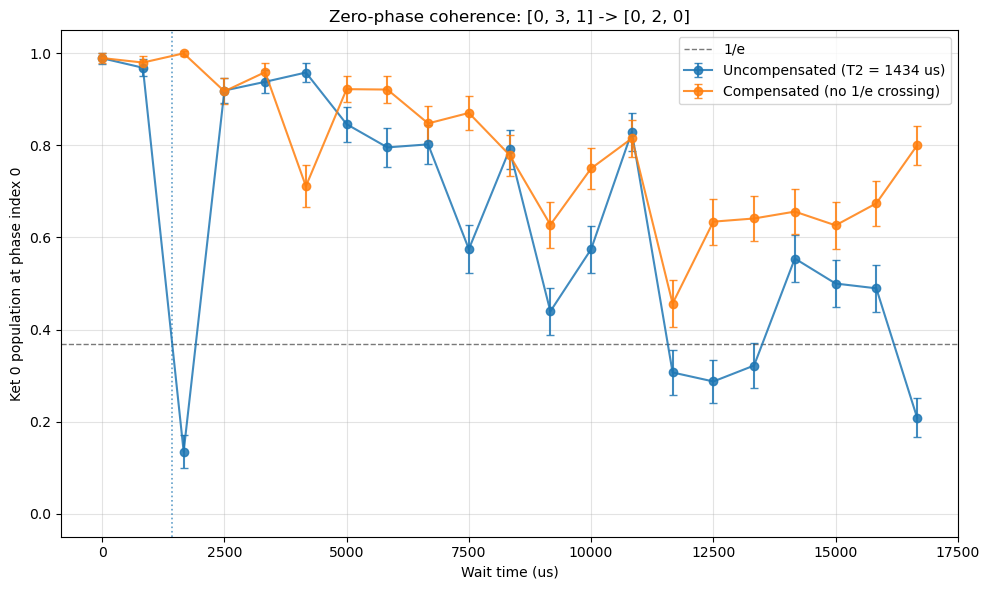

In [18]:
# Run the same-log/same-PD-file coherence analysis for both compensation modes.
records_by_mode, final_transitions, mean_devs = load_records_for_transition(target_transitions)
print(f"Transitions found: {final_transitions}")
print(f"Mean deviations from log: {mean_devs}")

zero_phase_scans = collect_zero_phase_scans(records_by_mode, zero_phase_index=ZERO_PHASE_INDEX)
if not zero_phase_scans:
    raise RuntimeError("No zero-phase scan results were produced.")

combined_points = combine_by_wait_time(zero_phase_scans)
if not combined_points:
    raise RuntimeError("No combined wait-time points were produced.")

estimates = {
    lt_comp: estimate_first_crossing(combined_points, lt_comp, threshold=T2_THRESHOLD)
    for lt_comp in [False, True]
}

for lt_comp, estimate in estimates.items():
    tag = "Compensated" if lt_comp else "Uncompensated"
    if estimate.crossed:
        print(
            f"{tag}: initial ket0={estimate.initial_population:.4f}, "
            f"1/e population mark={estimate.threshold_population:.4f}, "
            f"first crossing={estimate.t2_us:.2f} us"
        )
    elif estimate.initial_population is not None:
        print(
            f"{tag}: initial ket0={estimate.initial_population:.4f}, "
            f"1/e population mark={estimate.threshold_population:.4f}, "
            "no crossing in measured wait-time range"
        )
    else:
        print(f"{tag}: not enough finite data for a crossing estimate")

save_combined_table(combined_points, OUTPUT_TABLE)
plot_coherence(combined_points, estimates, OUTPUT_FIGURE)
